In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from collections import defaultdict

# ILLER sözlüğünü tanımlayalım
ILLER = {
    'Trabzon': [17038, 17037, 17775, 17465, 17714, 18229, 18233, 18231, 18232, 17626,
                17464, 17569, 18230, 17463, 18573, 18570, 18571, 18572, 18574, 18575,
                19063, 18936, 19061, 19064, 19246, 19062, 19060, 19247, 18978, 19366,
                19344, 19902, 19350],

    'Giresun': [17034, 17682, 17387, 17686, 18221, 18225, 18224, 18222, 17462, 18220,
                18223, 18561, 18560, 18562, 18558, 18559, 18563, 18720, 19054, 18721,
                18921, 19239, 19055, 18722, 19053, 18730, 19238, 19237, 19240, 19377],

    'Artvin': [17042, 18218, 17045, 18217, 17467, 18216, 18556, 18555, 18554, 18715,
               19047, 19049, 18970, 19046, 18933, 18931, 19048, 19233, 18717, 18714,
               18932, 19232, 18716, 17398, 18964, 19373, 18969, 18967, 18957, 18962,
               18965, 18966, 19901, 19925, 17495],

    'Rize': [17040, 17741, 17713, 17757, 17765, 17769, 17761, 17772, 17785, 17800,
             17466, 17781, 17628, 18569, 18566, 18568, 18567, 18732, 18905, 19367,
             19058, 18935, 19243, 18934, 18937, 19334, 19059, 18731, 18963, 17044]
}

    # csvt dosyasını oku, , ile ayrılmış
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2025110691D3_10cmtoprak_sicakligi_ortalama.csv',
                     sep=',', encoding='utf-8')

# İstasyon numarasına göre il ataması yap
print("\nİl atamaları yapılıyor...")

def find_city(station_no):
    for city, stations in ILLER.items():
        if station_no in stations:
            return city
    return None

# İl atamasını yap
df['Il'] = df['istasyon_no'].apply(find_city)


# Hangi istasyonların eşleşmediğini kontrol et
unmatched = df[df['Il'].isna()]
if len(unmatched) > 0:
    print(f"Uyarı: {len(unmatched)} satırda il eşleşmesi bulunamadı.")
    print(f"Eşleşmeyen istasyon numaraları: {unmatched['istasyon_no'].unique()[:10]}")
else:
    print("Tüm istasyon numaraları il eşleşmesi buldu.")

# Eşleşen verileri filtrele
df_matched = df[df['Il'].notna()].copy()
print(f"İl atanan satır sayısı: {len(df_matched)}")

# Tarih sütunu oluştur
print("\nTarih sütunu oluşturuluyor...")
df_matched['Tarih'] = pd.to_datetime(dict(year=df_matched['yil'], month=df_matched['ay'], day=df_matched['gun']))

# Aynı ildeki aynı tarihteki Toprak sıcaklığı medyanlarını al (ORTALAMA yerine MEDYAN kullanılıyor)
print("10cm Toprak sıcaklığı medyanları hesaplanıyor...")
grouped = df_matched.groupby(['Il', 'Tarih'])['deger'].median().reset_index()
grouped = grouped.sort_values(['Il', 'Tarih'])

# Medyan Toprak sıcaklığı verilerini 2 ondalık basamağa yuvarla
grouped['deger'] = grouped['deger'].round(2)

print(f"Gruplandırılmış veri satır sayısı: {len(grouped)}")
print("\nHer ilden örnek satırlar:")
for city in ILLER.keys():
    city_data = grouped[grouped['Il'] == city]
    if len(city_data) > 0:
        print(f"{city}: {len(city_data)} satır")
        print(f"  Tarih aralığı: {city_data['Tarih'].min().date()} - {city_data['Tarih'].max().date()}")
    else:
        print(f"{city}: Veri bulunamadı")

# Her il için boş tarihleri kontrol et
print("\n" + "="*70)
print("BOŞ TARİH ANALİZİ")
print("="*70)

missing_dates_by_city = {}
date_ranges_by_city = {}
all_city_dates = {}

for city in ILLER.keys():
    print(f"\n{city}:")

    city_data = grouped[grouped['Il'] == city]

    if len(city_data) == 0:
        print("  ⚠️  Bu il için veri bulunamadı!")
        missing_dates_by_city[city] = []
        date_ranges_by_city[city] = (None, None)
        all_city_dates[city] = set()
        continue

    # Tarih aralığını bul
    min_date = city_data['Tarih'].min()
    max_date = city_data['Tarih'].max()
    date_ranges_by_city[city] = (min_date, max_date)

    # Mevcut tarihler
    existing_dates = set(city_data['Tarih'])
    all_city_dates[city] = existing_dates

    # Beklenen tüm tarihleri oluştur
    expected_dates = set()
    current_date = min_date
    while current_date <= max_date:
        expected_dates.add(current_date)
        current_date += timedelta(days=1)

    # Eksik tarihleri bul
    missing_dates = sorted(expected_dates - existing_dates)
    missing_dates_by_city[city] = missing_dates

    # İstatistikleri yazdır
    total_days = len(expected_dates)
    filled_days = len(existing_dates)
    missing_days = len(missing_dates)

    print(f"  Tarih aralığı: {min_date.date()} - {max_date.date()}")
    print(f"  Toplam gün sayısı: {total_days:,}")
    print(f"  Dolu gün sayısı: {filled_days:,} ({filled_days/total_days*100:.1f}%)")
    print(f"  Eksik gün sayısı: {missing_days:,} ({missing_days/total_days*100:.1f}%)")

    if missing_days > 0:
        print(f"  İlk 5 eksik tarih:")
        for date in missing_dates[:5]:
            print(f"    • {date.date()}")

        # Eksik tarihleri yıllara göre analiz et
        missing_by_year = defaultdict(int)
        for date in missing_dates:
            missing_by_year[date.year] += 1

        print(f"  Yıllara göre eksik gün dağılımı:")
        for year in sorted(missing_by_year.keys()):
            print(f"    {year}: {missing_by_year[year]:,} gün")
    else:
        print("   Tüm tarihler dolu!")

# Özet tablo
print("\n" + "="*80)
print("ÖZET TABLOSU")
print("="*80)
print(f"{'İl':<10} {'Başlangıç':<12} {'Bitiş':<12} {'Top.Gün':<10} {'Dolu':<10} {'Eksik':<10} {'Doluluk':<10}")
print("-"*80)

for city in ILLER.keys():
    if city not in date_ranges_by_city or date_ranges_by_city[city][0] is None:
        print(f"{city:<10} {'-':<12} {'-':<12} {'-':<10} {'-':<10} {'-':<10} {'-':<10}")
        continue

    min_date, max_date = date_ranges_by_city[city]
    total_days = (max_date - min_date).days + 1
    filled_days = len(all_city_dates[city])
    missing_days = total_days - filled_days
    fill_rate = (filled_days / total_days * 100) if total_days > 0 else 0

    print(f"{city:<10} {min_date.date():<12} {max_date.date():<12} "
          f"{total_days:<10,} {filled_days:<10,} {missing_days:<10,} {fill_rate:>8.1f}%")

# İl bazında detaylı eksik tarih analizi
print("\n" + "="*80)
print("DETAYLI EKSİK TARİH ANALİZİ")
print("="*80)

for city, missing_dates in missing_dates_by_city.items():
    if missing_dates:
        print(f"\n{city} - Toplam {len(missing_dates):,} eksik gün:")

        # Eksik tarihleri yıllara ve aylara göre grupla
        yearly_monthly_counts = defaultdict(lambda: defaultdict(int))
        yearly_counts = defaultdict(int)

        for date in missing_dates:
            year = date.year
            month_key = f"{date.month:02d}"
            yearly_monthly_counts[year][month_key] += 1
            yearly_counts[year] += 1

        # Yıllara göre özet
        print(f"  Yıllara göre eksik gün sayısı:")
        for year in sorted(yearly_counts.keys()):
            print(f"    {year}: {yearly_counts[year]:,} gün")

        # En çok eksik olan yılları göster
        if yearly_counts:
            max_year = max(yearly_counts, key=yearly_counts.get)
            print(f"  En çok eksik: {max_year} yılı ({yearly_counts[max_year]:,} gün)")

            # Bu yılın aylık dağılımını göster
            print(f"  {max_year} yılı aylık dağılım:")
            for month in sorted(yearly_monthly_counts[max_year].keys()):
                month_name = datetime(2000, int(month), 1).strftime('%B')
                print(f"    {month_name}: {yearly_monthly_counts[max_year][month]:,} gün")

# Tüm illerin ortak tarih aralığını bul
print("\n" + "="*80)
print("ORTAK TARİH ARALIĞI ANALİZİ")
print("="*80)

# Tüm illerin tarih aralıklarını bul
all_min_dates = []
all_max_dates = []

for city, (min_date, max_date) in date_ranges_by_city.items():
    if min_date is not None:
        all_min_dates.append(min_date)
        all_max_dates.append(max_date)

if all_min_dates and all_max_dates:
    common_min = max(all_min_dates)  # En geç başlangıç
    common_max = min(all_max_dates)  # En erken bitiş

    print(f"Tüm illerin ortak tarih aralığı:")
    print(f"  Başlangıç (en geç): {common_min.date()}")
    print(f"  Bitiş (en erken): {common_max.date()}")

    if common_min <= common_max:
        total_common_days = (common_max - common_min).days + 1
        print(f"  Ortak gün sayısı: {total_common_days:,}")
    else:
        print("  ⚠️  Ortak tarih aralığı yok!")
else:
    print("Ortak tarih aralığı hesaplanamadı.")

    # Gruplandırılmış veriyi kaydet (MEDYAN hesaplamalı)
grouped.to_csv('/content/drive/MyDrive/il_bazinda_10cm_toprak_medyan_doldurulmus_ortalama.csv', index=False, encoding='utf-8')
print("İl bazında 10cm Toprak sıcaklığı dosyasına kaydedildi.")


İl atamaları yapılıyor...
Tüm istasyon numaraları il eşleşmesi buldu.
İl atanan satır sayısı: 161080

Tarih sütunu oluşturuluyor...
10cm Toprak sıcaklığı medyanları hesaplanıyor...
Gruplandırılmış veri satır sayısı: 67208

Her ilden örnek satırlar:
Trabzon: 16802 satır
  Tarih aralığı: 1980-01-01 - 2025-12-31
Giresun: 16802 satır
  Tarih aralığı: 1980-01-01 - 2025-12-31
Artvin: 16802 satır
  Tarih aralığı: 1980-01-01 - 2025-12-31
Rize: 16802 satır
  Tarih aralığı: 1980-01-01 - 2025-12-31

BOŞ TARİH ANALİZİ

Trabzon:
  Tarih aralığı: 1980-01-01 - 2025-12-31
  Toplam gün sayısı: 16,802
  Dolu gün sayısı: 16,802 (100.0%)
  Eksik gün sayısı: 0 (0.0%)
   Tüm tarihler dolu!

Giresun:
  Tarih aralığı: 1980-01-01 - 2025-12-31
  Toplam gün sayısı: 16,802
  Dolu gün sayısı: 16,802 (100.0%)
  Eksik gün sayısı: 0 (0.0%)
   Tüm tarihler dolu!

Artvin:
  Tarih aralığı: 1980-01-01 - 2025-12-31
  Toplam gün sayısı: 16,802
  Dolu gün sayısı: 16,802 (100.0%)
  Eksik gün sayısı: 0 (0.0%)
   Tüm tarihler

In [ ]:
def mevsim_belirle(tarih):
    ay = tarih.month
    gun = tarih.day

    if (ay == 3 and gun >= 21) or (4 <= ay <= 5) or (ay == 6 and gun <= 20):
        return "İlkbahar"
    elif (ay == 6 and gun >= 21) or (7 <= ay <= 8) or (ay == 9 and gun <= 22):
        return "Yaz"
    elif (ay == 9 and gun >= 23) or (10 <= ay <= 11) or (ay == 12 and gun <= 20):
        return "Sonbahar"
    else:
        return "Kış"

In [ ]:
data = pd.read_csv(
    "/content/drive/MyDrive/il_bazinda_10cm_toprak_ortalamalar.csv",
    encoding="utf-8"
)

data["Tarih"] = pd.to_datetime(data["Tarih"])
data["Yil"] = data["Tarih"].dt.year
data["Ay"] = data["Tarih"].dt.month
data["Mevsim"] = data["Tarih"].apply(mevsim_belirle)


In [ ]:
grouped["Mevsim"] = grouped["Tarih"].apply(mevsim_belirle)
grouped["Yil"] = grouped["Tarih"].dt.year


In [ ]:
trend_sonuclari = []

iller = grouped["Il"].unique()
mevsimler = ["İlkbahar", "Yaz", "Sonbahar", "Kış"]

for il in iller:
    for mevsim in mevsimler:

        temp = grouped[
            (grouped["Il"] == il) &
            (grouped["Mevsim"] == mevsim)
        ]

        # Yıllık ortalama
        yillik = temp.groupby("Yil")["deger"].mean().reset_index()
        yillik = yillik.sort_values("Yil")

        if len(yillik) < 5:
            continue

        ilk_yil = yillik.iloc[0]["Yil"]
        son_yil = yillik.iloc[-1]["Yil"]

        ilk_deger = yillik.iloc[0]["deger"]
        son_deger = yillik.iloc[-1]["deger"]

        yil_sayisi = son_yil - ilk_yil

        if yil_sayisi == 0:
            continue

        yillik_artis = (son_deger - ilk_deger) / yil_sayisi
        on_yillik_artis = yillik_artis * 10

        trend_sonuclari.append({
            "Il": il,
            "Mevsim": mevsim,
            "Yillik_Artis (°C/yil)": round(yillik_artis, 4),
            "10_Yillik_Artis (°C/10yil)": round(on_yillik_artis, 3)
        })

trend_df = pd.DataFrame(trend_sonuclari)
trend_df


,Il,Mevsim,Yillik_Artis (°C/yil),10_Yillik_Artis (°C/10yil)
0,Artvin,İlkbahar,-0.0336,-0.336
1,Artvin,Yaz,-0.0140,-0.140
2,Artvin,Sonbahar,0.1045,1.045
3,Artvin,Kış,-0.0043,-0.043
4,Giresun,İlkbahar,-0.0081,-0.081
5,Giresun,Yaz,0.0045,0.045
6,Giresun,Sonbahar,0.0515,0.515
7,Giresun,Kış,-0.0436,-0.436
8,Rize,İlkbahar,0.0026,0.026
9,Rize,Yaz,0.0139,0.139


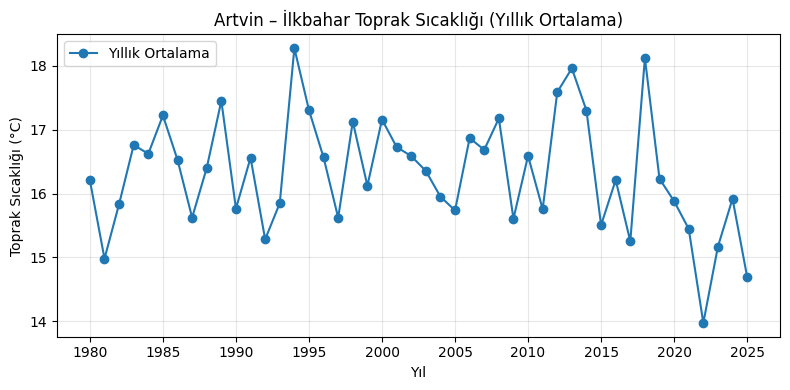

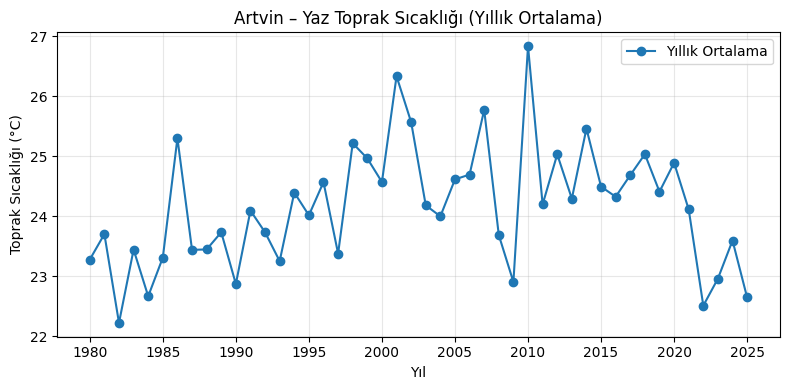

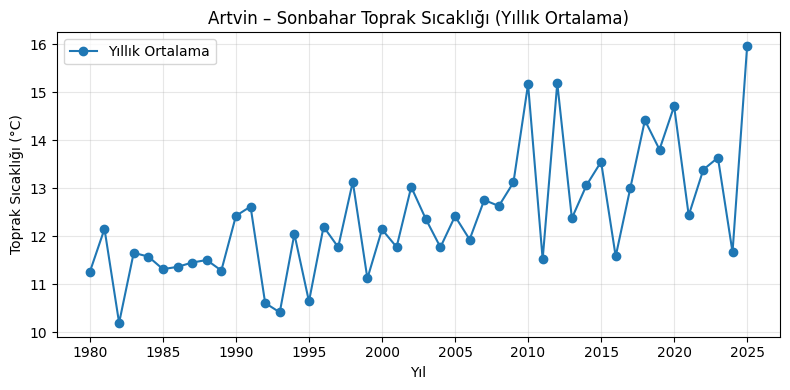

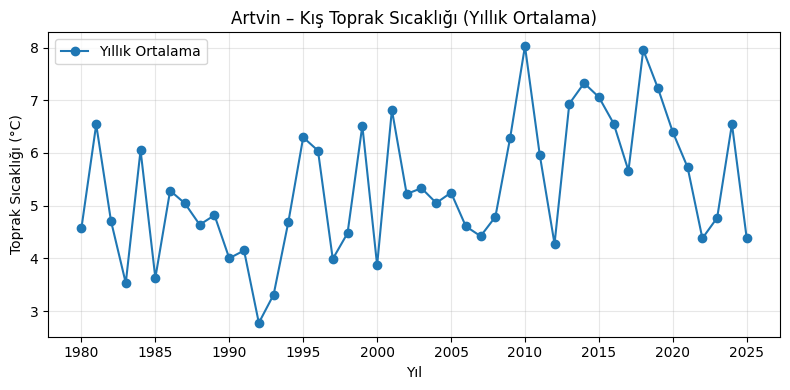

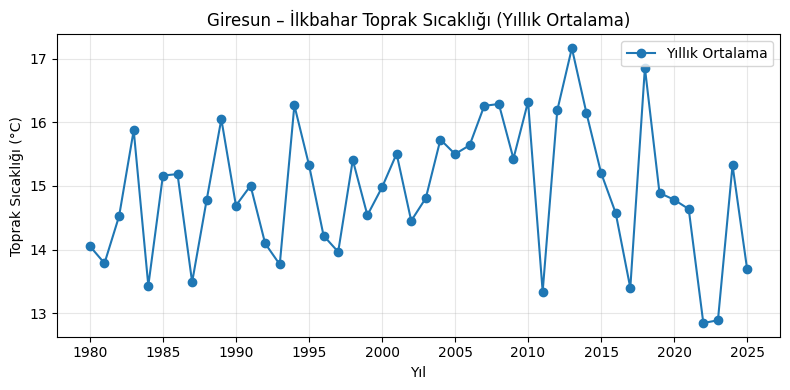

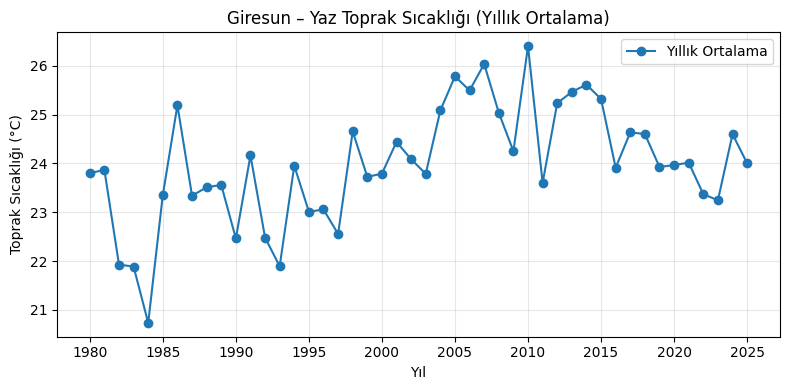

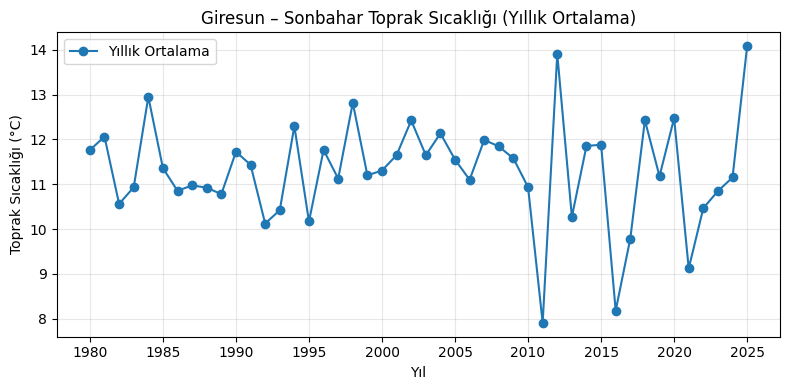

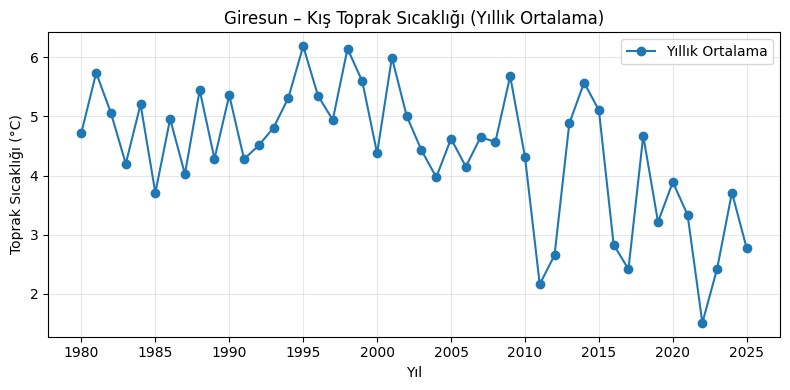

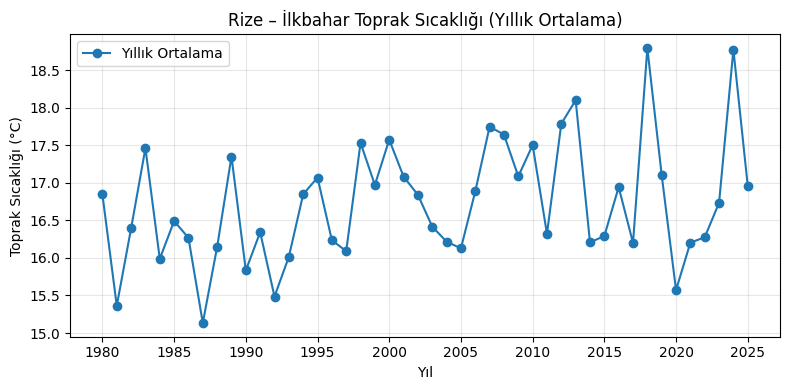

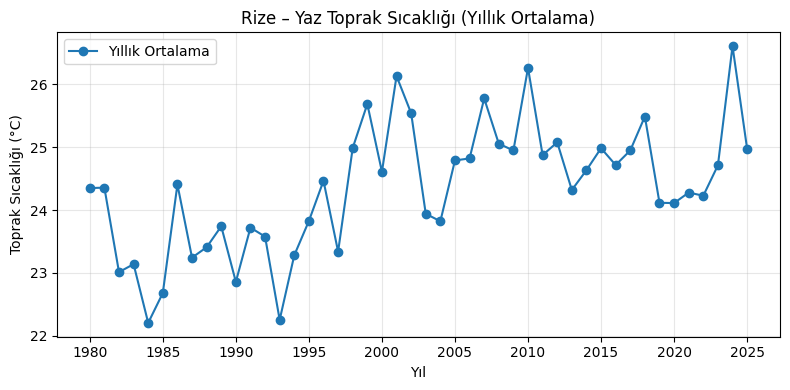

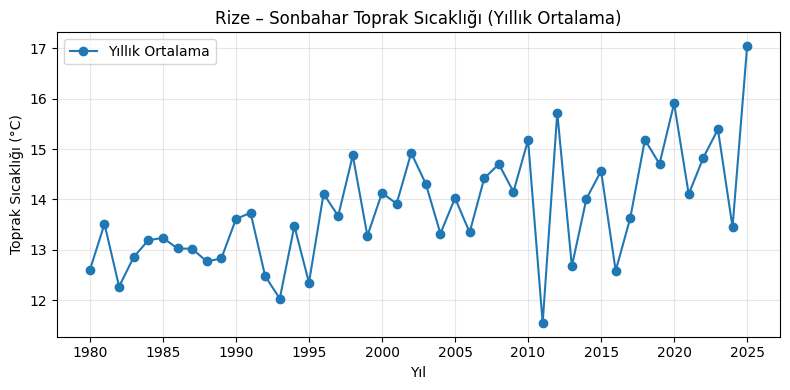

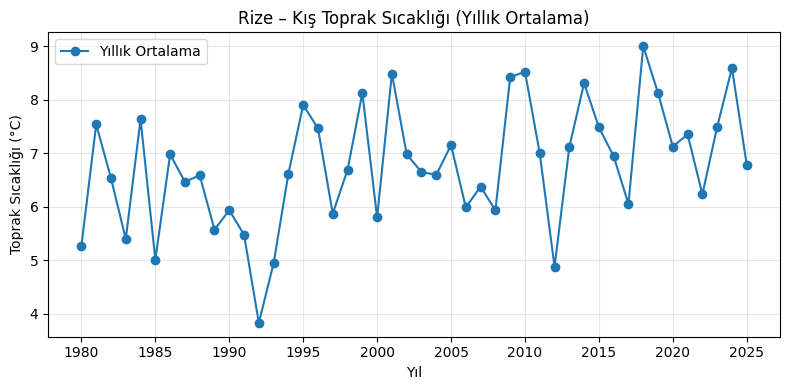

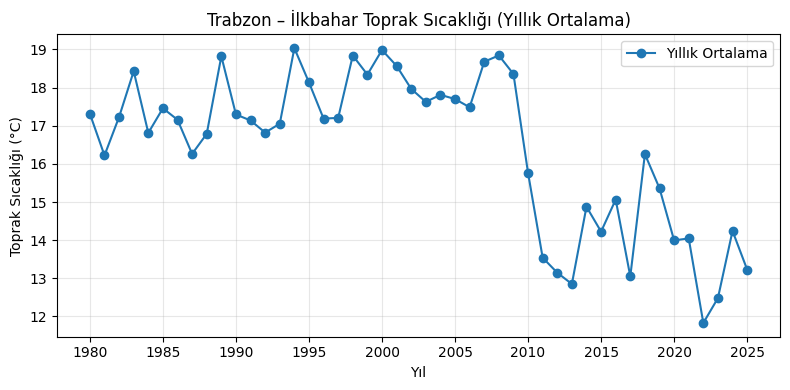

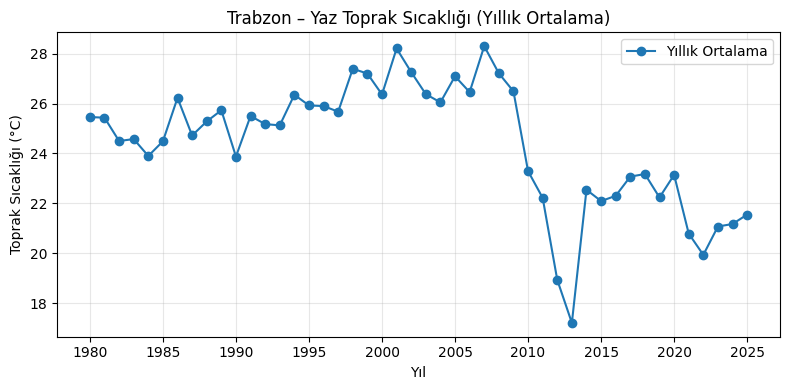

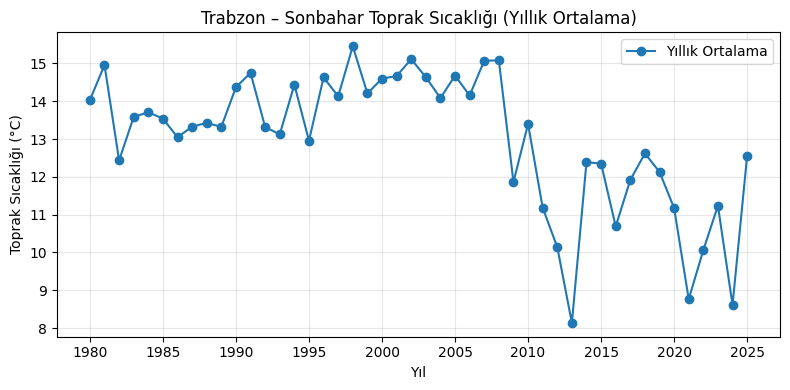

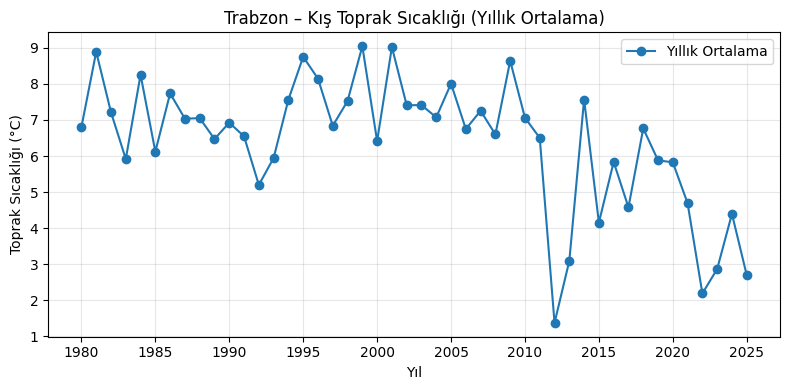

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for il in iller:
    for mevsim in mevsimler:

        temp = grouped[
            (grouped["Il"] == il) &
            (grouped["Mevsim"] == mevsim)
        ]

        yillik = temp.groupby("Yil")["deger"].mean()

        if len(yillik) < 5:
            continue

        x = yillik.index.values
        y = yillik.values

        plt.figure(figsize=(8, 4))
        plt.plot(x, y, marker="o", label="Yıllık Ortalama")

        plt.xticks(np.arange(x.min(), x.max() + 1, 5))
        plt.title(f"{il} – {mevsim} Toprak Sıcaklığı (Yıllık Ortalama)")
        plt.xlabel("Yıl")
        plt.ylabel("Toprak Sıcaklığı (°C)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


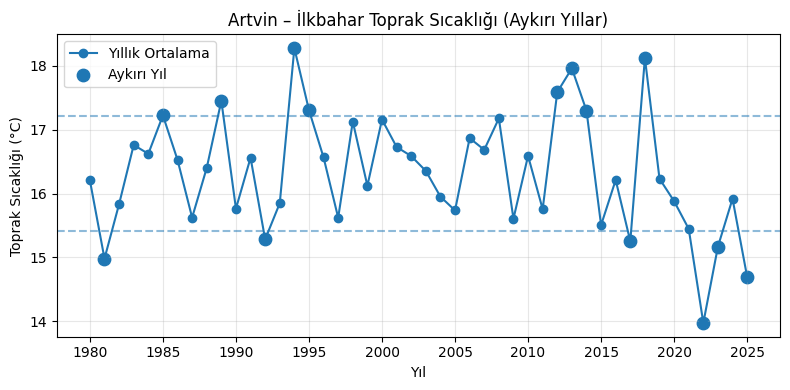

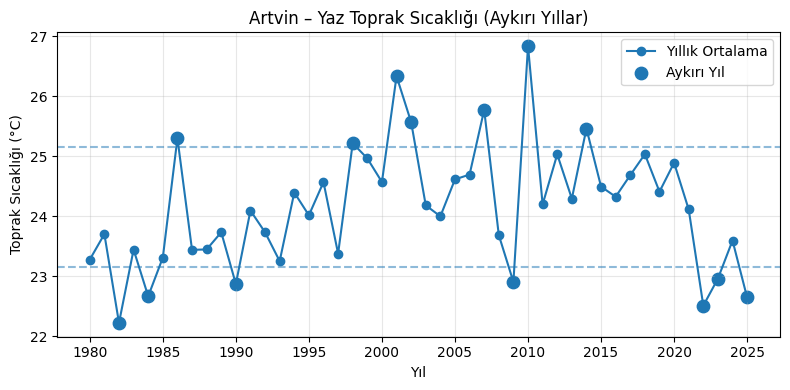

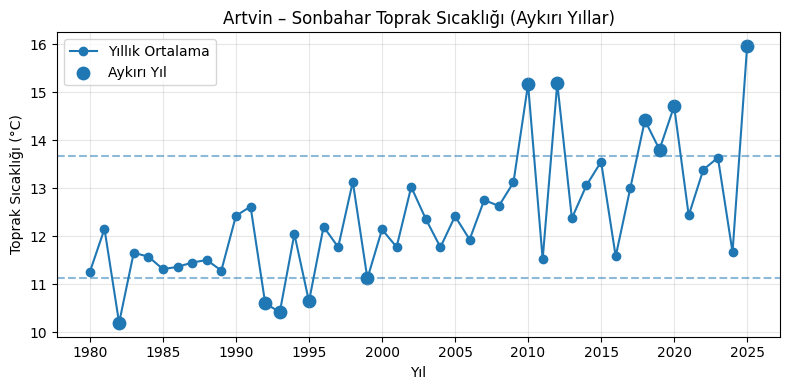

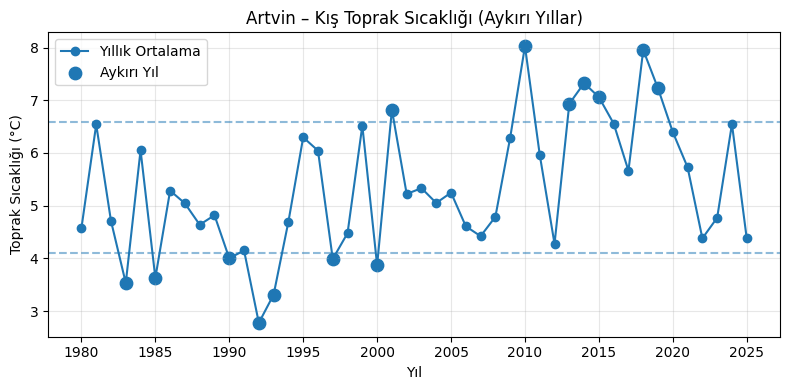

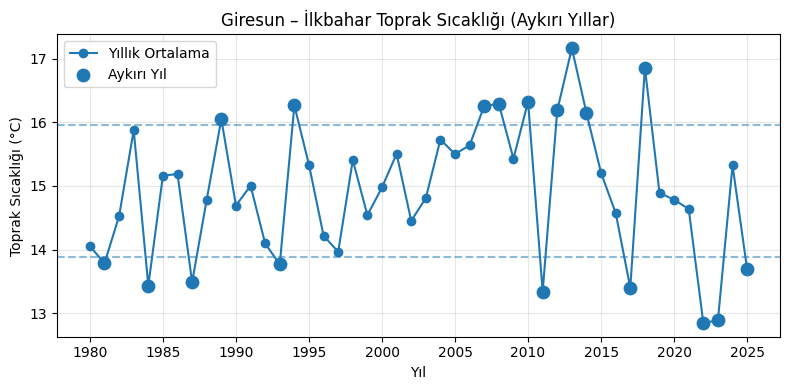

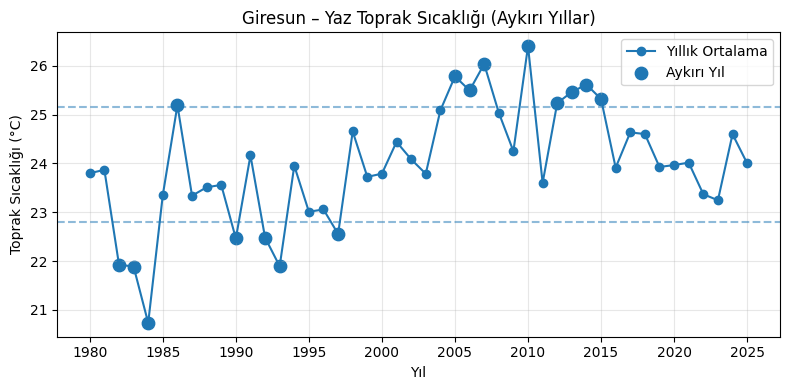

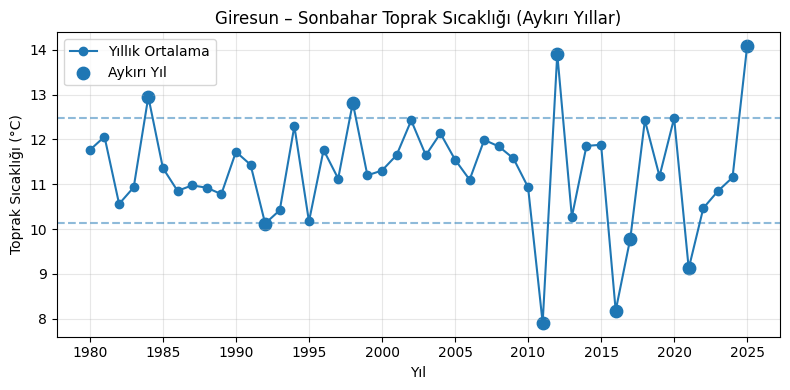

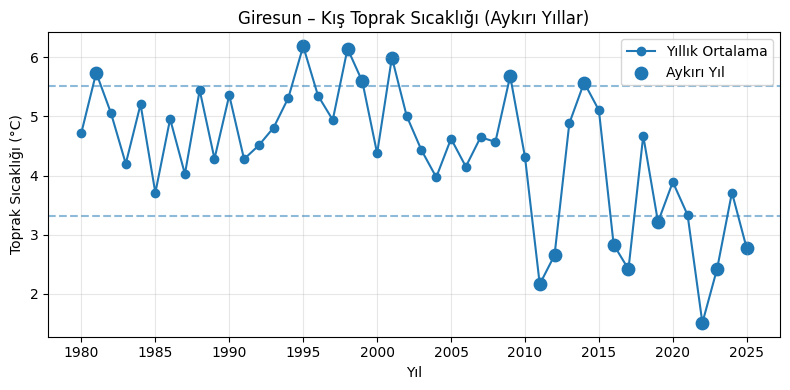

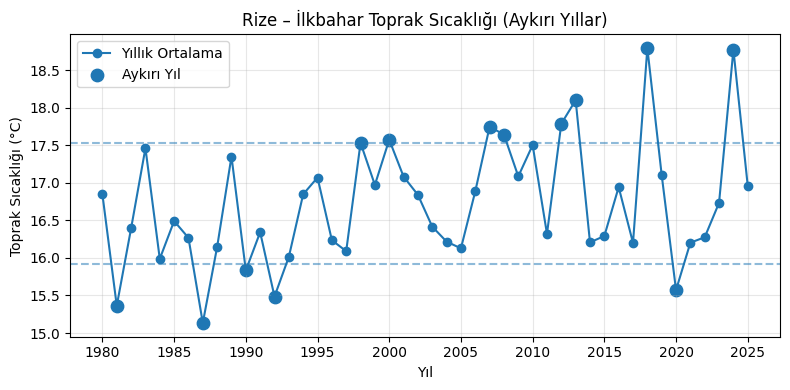

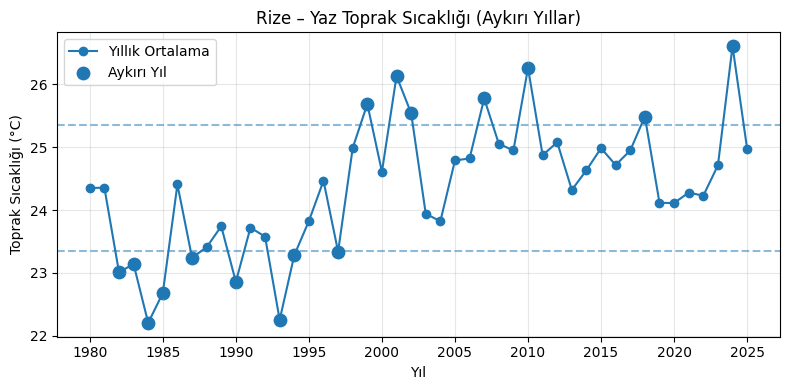

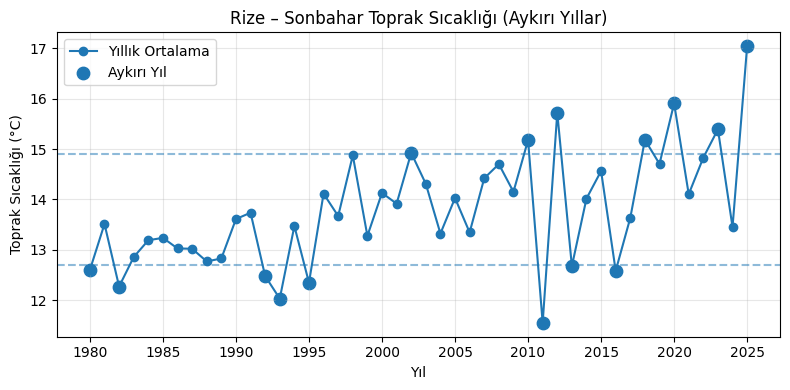

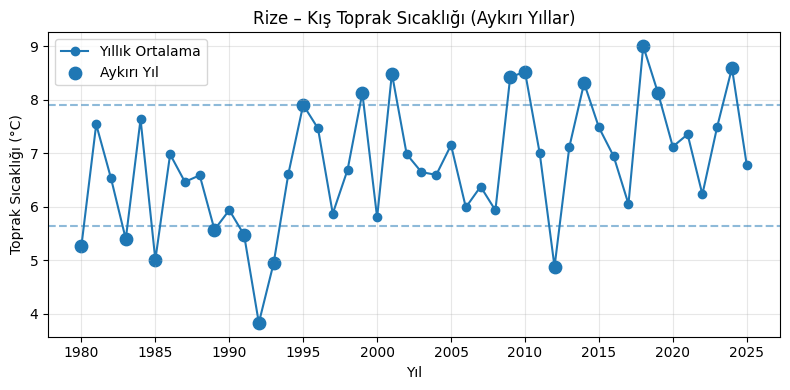

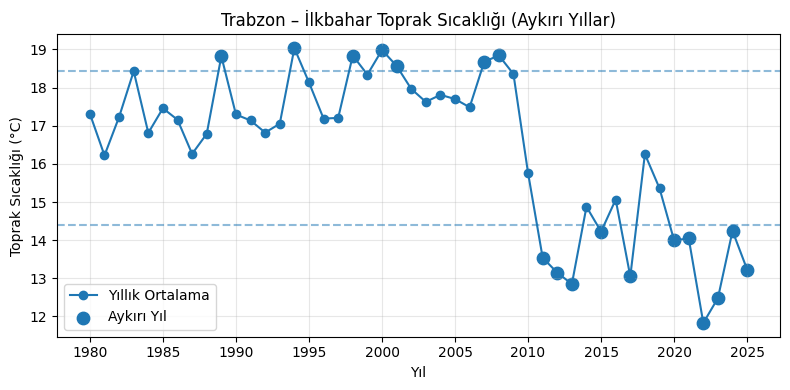

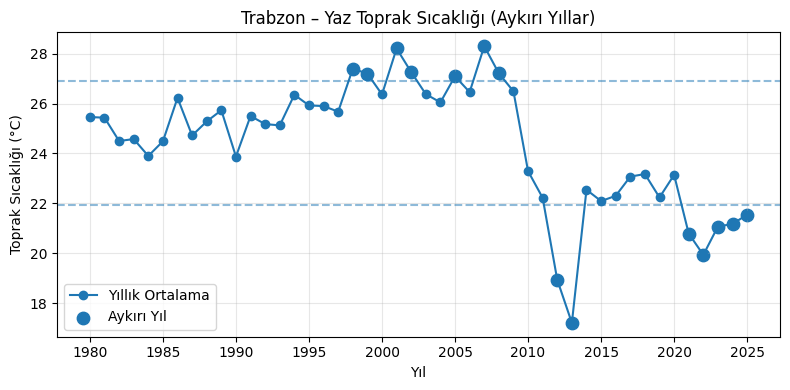

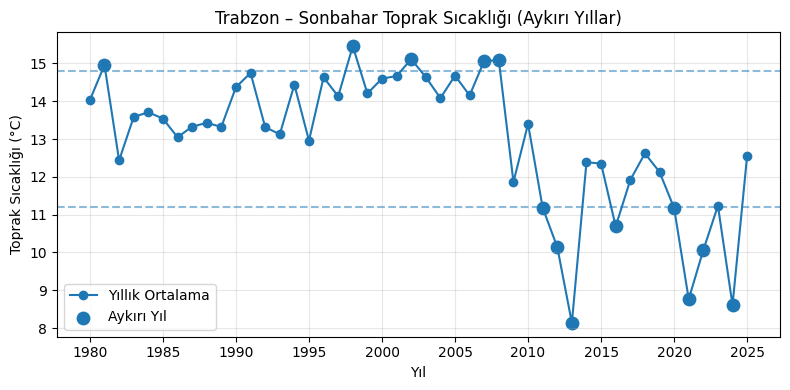

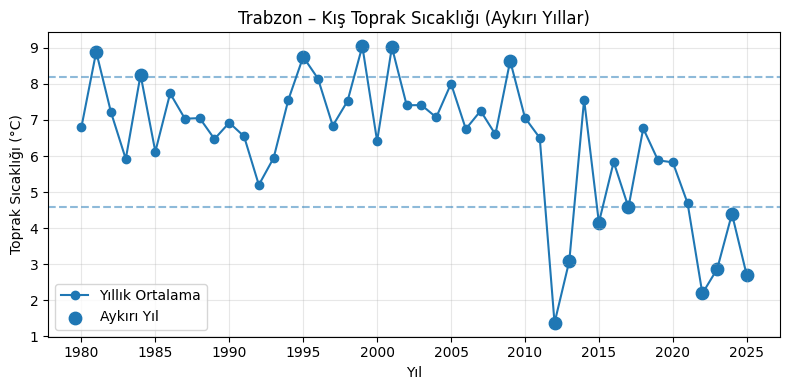

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for il in iller:
    for mevsim in mevsimler:

        temp = grouped[
            (grouped["Il"] == il) &
            (grouped["Mevsim"] == mevsim)
        ]

        yillik = temp.groupby("Yil")["deger"].mean()

        if len(yillik) < 5:
            continue

        x = yillik.index.values
        y = yillik.values

        # Aykırı değer hesaplama
        ortalama = y.mean()
        std = y.std()

        ust_esik = ortalama + std
        alt_esik = ortalama - std

        aykiri_mask = (y > ust_esik) | (y < alt_esik)

        plt.figure(figsize=(8, 4))

        # Normal yıllar
        plt.plot(x, y, marker="o", label="Yıllık Ortalama")

        # Aykırı yıllar
        plt.scatter(
            x[aykiri_mask],
            y[aykiri_mask],
            s=80,
            marker="o",
            label="Aykırı Yıl"
        )

        plt.axhline(ust_esik, linestyle="--", alpha=0.5)
        plt.axhline(alt_esik, linestyle="--", alpha=0.5)

        plt.xticks(np.arange(x.min(), x.max() + 1, 5))
        plt.title(f"{il} – {mevsim} Toprak Sıcaklığı (Aykırı Yıllar)")
        plt.xlabel("Yıl")
        plt.ylabel("Toprak Sıcaklığı (°C)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


In [ ]:
“Uzun dönem ortalamasından standart sapma bazlı eşiklerle ayrışan yıllar aykırı olarak işaretlenmiş, iklimsel anormalliklerin görsel olarak tespit edilmesi sağlanmıştır.”

In [ ]:
aykiri_kayitlar = []

for il in iller:
    for mevsim in mevsimler:

        temp = grouped[
            (grouped["Il"] == il) &
            (grouped["Mevsim"] == mevsim)
        ]

        yillik = temp.groupby("Yil")["deger"].mean().reset_index()

        if len(yillik) < 5:
            continue

        ortalama = yillik["deger"].mean()
        std = yillik["deger"].std()

        ust_esik = ortalama + std
        alt_esik = ortalama - std

        aykiri = yillik[
            (yillik["deger"] > ust_esik) |
            (yillik["deger"] < alt_esik)
        ]

        for _, row in aykiri.iterrows():
            aykiri_kayitlar.append({
                "Il": il,
                "Mevsim": mevsim,
                "Yil": int(row["Yil"]),
                "Toprak_Sicakligi_Ort (°C)": round(row["deger"], 2),
                "Uzun_Donem_Ort (°C)": round(ortalama, 2),
                "Alt_Esik (°C)": round(alt_esik, 2),
                "Ust_Esik (°C)": round(ust_esik, 2),
                "Sapma (°C)": round(row["deger"] - ortalama, 2)
            })

aykiri_df = pd.DataFrame(aykiri_kayitlar)
aykiri_df


,Il,Mevsim,Yil,Toprak_Sicakligi_Ort (°C),Uzun_Donem_Ort (°C),Alt_Esik (°C),Ust_Esik (°C),Sapma (°C)
0,Artvin,İlkbahar,1981,14.98,16.32,15.41,17.22,-1.34
1,Artvin,İlkbahar,1989,17.45,16.32,15.41,17.22,1.14
2,Artvin,İlkbahar,1992,15.28,16.32,15.41,17.22,-1.03
3,Artvin,İlkbahar,1994,18.28,16.32,15.41,17.22,1.96
4,Artvin,İlkbahar,1995,17.31,16.32,15.41,17.22,0.99
...,...,...,...,...,...,...,...,...
219,Trabzon,Kış,2015,4.15,6.39,4.57,8.22,-2.24
220,Trabzon,Kış,2022,2.19,6.39,4.57,8.22,-4.20
221,Trabzon,Kış,2023,2.87,6.39,4.57,8.22,-3.52
222,Trabzon,Kış,2024,4.40,6.39,4.57,8.22,-2.00


In [ ]:
“Uzun dönem ortalamasına göre standart sapma bazlı eşikler kullanılarak olağan dışı sıcaklık değerleri tespit edilmiş, aykırı yıllar detaylı bir tablo halinde raporlanmıştır.”

In [ ]:
# Aykırı yıl sayısını KPI olarak özetleme
kpi_aykiri_sayisi = (
    aykiri_df
    .groupby(["Il", "Mevsim"])
    .agg(
        Aykiri_Yil_Sayisi=("Yil", "count"),
        Ilk_Aykiri_Yil=("Yil", "min"),
        Son_Aykiri_Yil=("Yil", "max")
    )
    .reset_index()
)

kpi_aykiri_sayisi


,Il,Mevsim,Aykiri_Yil_Sayisi,Ilk_Aykiri_Yil,Son_Aykiri_Yil
0,Artvin,Kış,14,1983,2019
1,Artvin,Sonbahar,10,1982,2025
2,Artvin,Yaz,14,1982,2025
3,Artvin,İlkbahar,13,1981,2025
4,Giresun,Kış,15,1981,2025
5,Giresun,Sonbahar,8,1984,2025
6,Giresun,Yaz,16,1982,2015
7,Giresun,İlkbahar,18,1981,2025
8,Rize,Kış,16,1980,2024
9,Rize,Sonbahar,15,1980,2025


In [ ]:
“Aykırı sıcaklık gözlemleri KPI’laştırılarak il ve mevsim bazında aykırı yıl sayıları hesaplanmış, iklimsel anomalilerin yoğunluğu ve sürekliliği ölçülebilir hale getirilmiştir.”